# Feature engineering a partir da base tratada

Proposta:
- partir do `credit_score_clean.csv`
- analisar sinais que justifiquem criacao de features
- decidir quais delas entram no `build_features.py`


## 1. Objetivo

A logica do projeto fica assim:

- `01_analise_exploratoria.ipynb` analisa a base bruta e fundamenta o `preprocess.py`
- `02_feature_engineering.ipynb` analisa a base tratada e fundamenta o `build_features.py`
- `main.py` executa o workflow reprodutivel

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.features.build_features import build_features_pipeline

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', 200)

CLEAN_PATH = PROJECT_ROOT / 'data' / 'processed' / 'credit_score_clean.csv'
df = pd.read_csv(CLEAN_PATH)

print(f'Caminho: {CLEAN_PATH.resolve()}')
print(f'Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas')

Caminho: C:\Users\guilh\repos_github\credit-scoring-model\data\processed\credit_score_clean.csv
Shape: 100,000 linhas x 26 colunas


In [4]:
df.head()

,Customer_ID,Month,Month_Num,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Months,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,target
0,CUS_0x1000,January,1,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",62,25,1.63,10,Bad,1562.91,26.612093,122,Yes,42.94109,244.750283,Low_spent_Large_value_payments,252.924793,0
1,CUS_0x1000,February,2,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",62,23,1.63,11,Bad,1562.91,29.439759,123,Yes,42.94109,176.132567,High_spent_Small_value_payments,311.542510,1
2,CUS_0x1000,March,3,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",62,28,1.63,11,Bad,1562.91,38.285928,124,Yes,42.94109,109.056519,High_spent_Medium_value_payments,368.618557,1
3,CUS_0x1000,April,4,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",64,25,1.63,11,Bad,1562.91,32.843081,125,Yes,42.94109,87.909909,High_spent_Medium_value_payments,419.765167,1
4,CUS_0x1000,May,5,18,Lawyer,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, Home Equity Loan",67,25,2.63,11,Bad,1562.91,32.330508,126,Yes,42.94109,191.834767,Low_spent_Large_value_payments,305.840309,1


## 2. Features para análise de crédito

Em projetos de análise de crédito, é interessante priorizar features que sejam:
- interpretaveis para negocio
- calculaveis de forma reproduzivel


In [5]:
df_work = df.copy()

df_work['Loan_Type_Count'] = df_work['Type_of_Loan'].apply(
    lambda value: 0 if pd.isna(value) or value == 'Unknown' else len([x.strip() for x in str(value).split(',') if x.strip()])
)
df_work['Has_Min_Payment_Only'] = (df_work['Payment_of_Min_Amount'] == 'Yes').astype(int)
df_work['Is_Bad_Credit_Mix'] = (df_work['Credit_Mix'] == 'Bad').astype(int)

df_work['Debt_to_Income_Ratio'] = df_work['Outstanding_Debt'] / df_work['Annual_Income'].replace(0, np.nan)
df_work['EMI_to_Income_Ratio'] = df_work['Total_EMI_per_month'] / df_work['Monthly_Inhand_Salary'].replace(0, np.nan)
df_work['Invested_to_Income_Ratio'] = df_work['Amount_invested_monthly'] / df_work['Monthly_Inhand_Salary'].replace(0, np.nan)
df_work['Balance_to_Income_Ratio'] = df_work['Monthly_Balance'] / df_work['Monthly_Inhand_Salary'].replace(0, np.nan)

df_work['Delay_x_Inquiries'] = df_work['Delay_from_due_date'] * df_work['Num_Credit_Inquiries']
df_work['Utilization_x_Debt'] = df_work['Credit_Utilization_Ratio'] * df_work['Outstanding_Debt']

approved_features = [
    'Loan_Type_Count',
    'Has_Min_Payment_Only',
    'Is_Bad_Credit_Mix',
    'Debt_to_Income_Ratio',
    'EMI_to_Income_Ratio',
    'Invested_to_Income_Ratio',
    'Balance_to_Income_Ratio',
    'Delay_x_Inquiries',
    'Utilization_x_Debt'
]

for col in approved_features:
    if df_work[col].dtype.kind in 'biufc':
        df_work[col] = df_work[col].replace([np.inf, -np.inf], np.nan)
        df_work[col] = df_work[col].fillna(df_work[col].median())

df_work[approved_features + ['target']].head()

,Loan_Type_Count,Has_Min_Payment_Only,Is_Bad_Credit_Mix,Debt_to_Income_Ratio,EMI_to_Income_Ratio,Invested_to_Income_Ratio,Balance_to_Income_Ratio,Delay_x_Inquiries,Utilization_x_Debt,target
0,2,1,1,0.051032,0.015868,0.090442,0.093463,620,41592.306407,0
1,2,1,1,0.051032,0.015868,0.065086,0.115123,682,46011.693758,1
2,2,1,1,0.051032,0.015868,0.040299,0.136215,682,59837.459708,1
3,2,1,1,0.051032,0.015868,0.032485,0.155115,704,51330.780120,1
4,2,1,1,0.051032,0.015868,0.070888,0.113016,737,50529.674519,1


In [6]:
corr_approved = (
    df_work[approved_features + ['target']]
    .corr(numeric_only=True)['target']
    .drop('target')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_approved.to_frame('corr_target')

,corr_target
Delay_x_Inquiries,0.406783
Is_Bad_Credit_Mix,0.382963
Utilization_x_Debt,0.349573
Loan_Type_Count,0.319454
Has_Min_Payment_Only,0.283879
Debt_to_Income_Ratio,0.280189
Balance_to_Income_Ratio,0.106134
Invested_to_Income_Ratio,0.057930
EMI_to_Income_Ratio,0.016694


## 3. Features selecionadas

A partir da analise, as features incluídas na pipeline são:

- `Loan_Type_Count`
- `Has_Min_Payment_Only`
- `Is_Bad_Credit_Mix`
- `Debt_to_Income_Ratio`
- `EMI_to_Income_Ratio`
- `Invested_to_Income_Ratio`
- `Balance_to_Income_Ratio`
- `Delay_x_Inquiries`
- `Utilization_x_Debt`


## 4. Evidencia 1: complexidade do endividamento

A coluna `Type_of_Loan` tem alta cardinalidade (grande quantidade de valores exclusivos). A contagem de tipos de emprestimo resume bem a complexidade do perfil de credito.

In [7]:
df_work.groupby('target')['Loan_Type_Count'].describe()[['mean', '50%', 'std']].round(3)

,mean,50%,std
target,,,
0,3.033,3.0,2.268
1,4.756,5.0,2.436


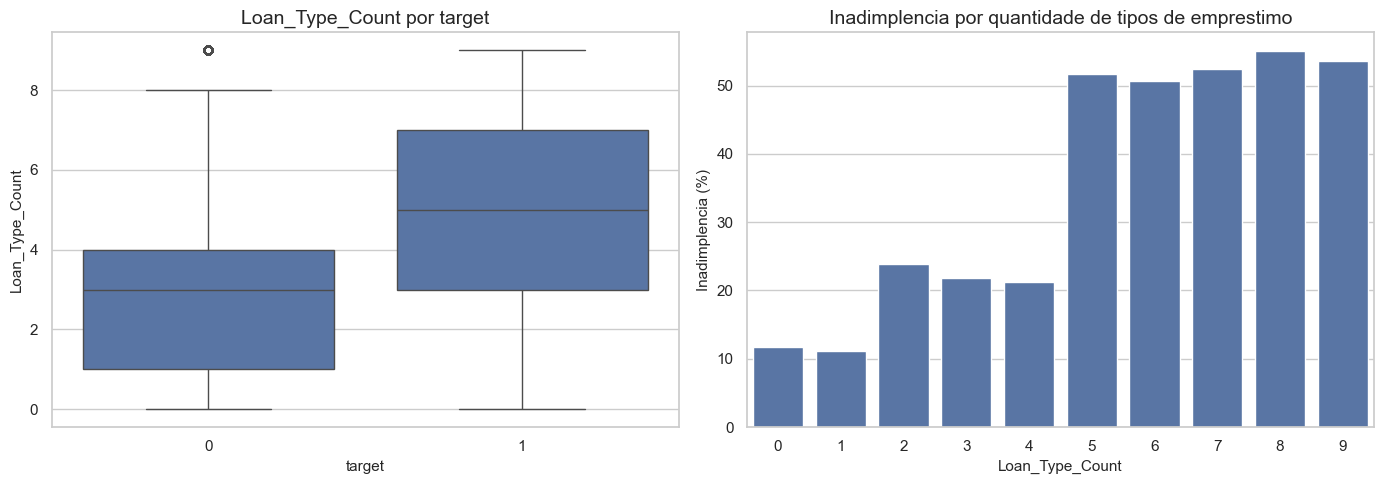

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_work, x='target', y='Loan_Type_Count', ax=axes[0])
axes[0].set_title('Loan_Type_Count por target')

loan_rate = df_work.groupby('Loan_Type_Count')['target'].agg(['size', 'mean']).reset_index()
loan_rate['mean'] = loan_rate['mean'] * 100
sns.barplot(data=loan_rate, x='Loan_Type_Count', y='mean', ax=axes[1])
axes[1].set_title('Inadimplencia por quantidade de tipos de emprestimo')
axes[1].set_ylabel('Inadimplencia (%)')

plt.tight_layout()
plt.show()

## 5. Evidencia 2: comportamento de pagamento e composicao de credito

Duas variaveis categoricas ficaram especialmente fortes:
- pagar apenas o minimo da fatura
- ter `Credit_Mix = Bad`

Elas viraram flags binarias para facilitar uso e interpretacao.

In [9]:
for col in ['Payment_of_Min_Amount', 'Credit_Mix']:
    summary = df.groupby(col)['target'].agg(['size', 'mean']).sort_values('size', ascending=False)
    summary['mean'] = (summary['mean'] * 100).round(2)
    print(f'\n### {col}')
    display(summary)


### Payment_of_Min_Amount


,size,mean
Payment_of_Min_Amount,,
Yes,59432,39.64
No,40568,13.41



### Credit_Mix


,size,mean
Credit_Mix,,
Standard,45848,21.50
Good,30384,15.97
Bad,23768,60.12


In [10]:
df_work.groupby('target')[['Has_Min_Payment_Only', 'Is_Bad_Credit_Mix']].mean().T.round(4)

target,0,1
Has_Min_Payment_Only,0.5052,0.8124
Is_Bad_Credit_Mix,0.1335,0.4928


## 6. Evidencia 3: razoes financeiras

As razoes reduzem o efeito de escala e tornam comparacoes entre clientes mais justas. Aqui vemos que divida relativa e saldo relativo ajudam mais do que renda ou divida em termos absolutos.

In [11]:
ratio_cols = [
    'Debt_to_Income_Ratio',
    'EMI_to_Income_Ratio',
    'Invested_to_Income_Ratio',
    'Balance_to_Income_Ratio'
]

df_work.groupby('target')[ratio_cols].median().T.round(4)

target,0,1
Debt_to_Income_Ratio,0.0185,0.0628
EMI_to_Income_Ratio,0.0217,0.0358
Invested_to_Income_Ratio,0.0424,0.0489
Balance_to_Income_Ratio,0.1130,0.1240


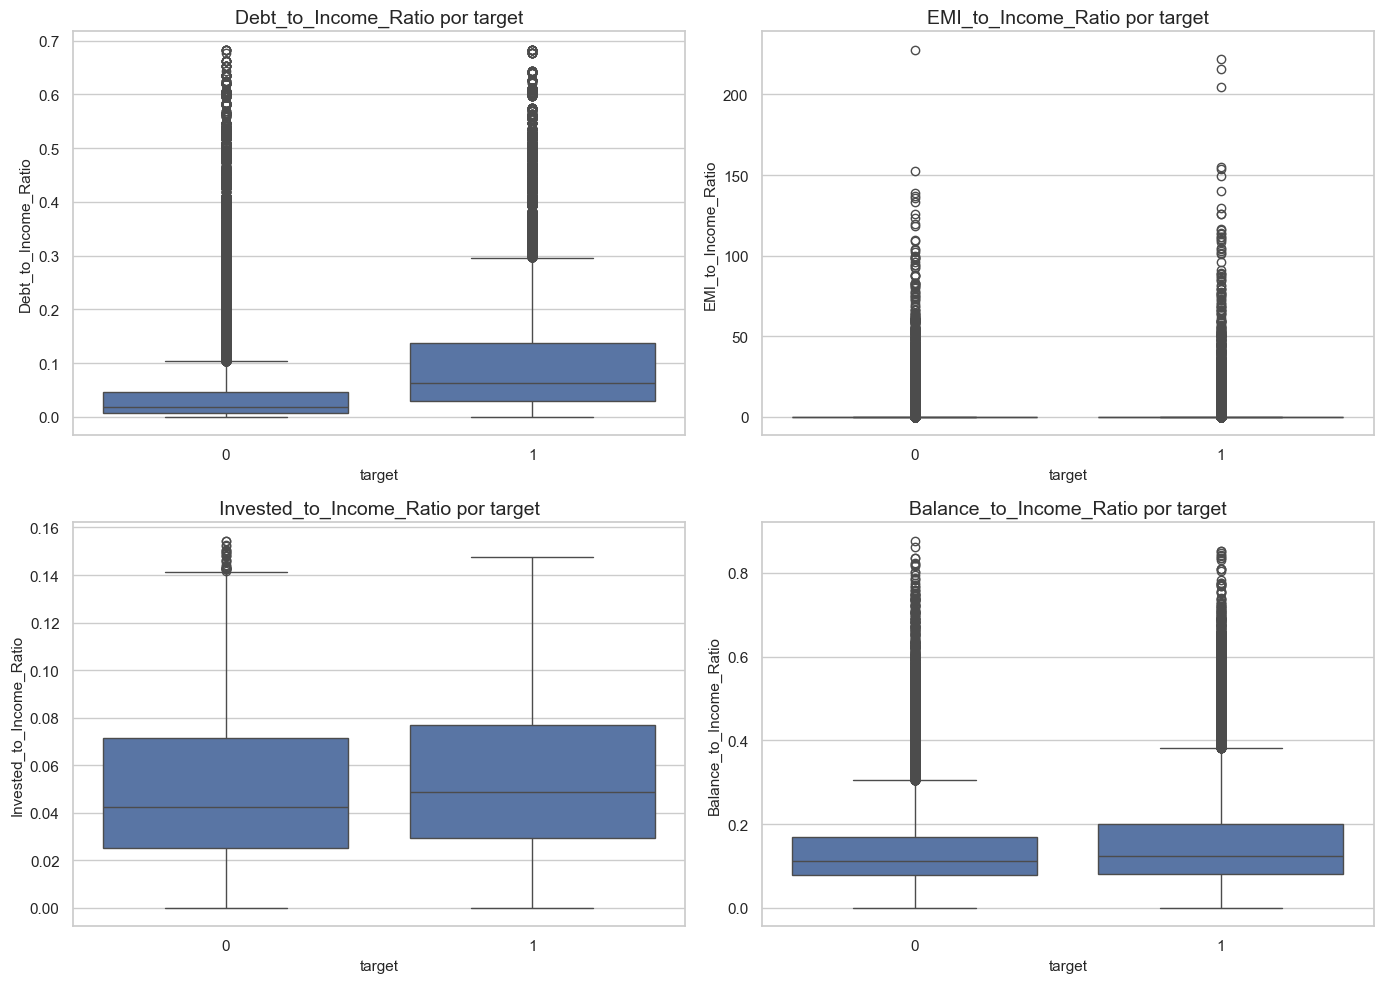

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, ratio_cols):
    sns.boxplot(data=df_work, x='target', y=col, ax=ax)
    ax.set_title(f'{col} por target')

plt.tight_layout()
plt.show()

## 7. Evidencia 4: interacoes entre atraso, consultas e utilizacao

Duas interacoes ficaram mais fortes que varias features simples:
- `Delay_x_Inquiries`: combina atraso com intensidade de consultas de credito
- `Utilization_x_Debt`: combina uso do limite com nivel de divida

Essas features ajudam a capturar pressao financeira de forma nao linear.

In [13]:
interaction_cols = ['Delay_x_Inquiries', 'Utilization_x_Debt']
df_work.groupby('target')[interaction_cols].median().T.round(2)

target,0,1
Delay_x_Inquiries,52.00,228.00
Utilization_x_Debt,29171.63,60373.54


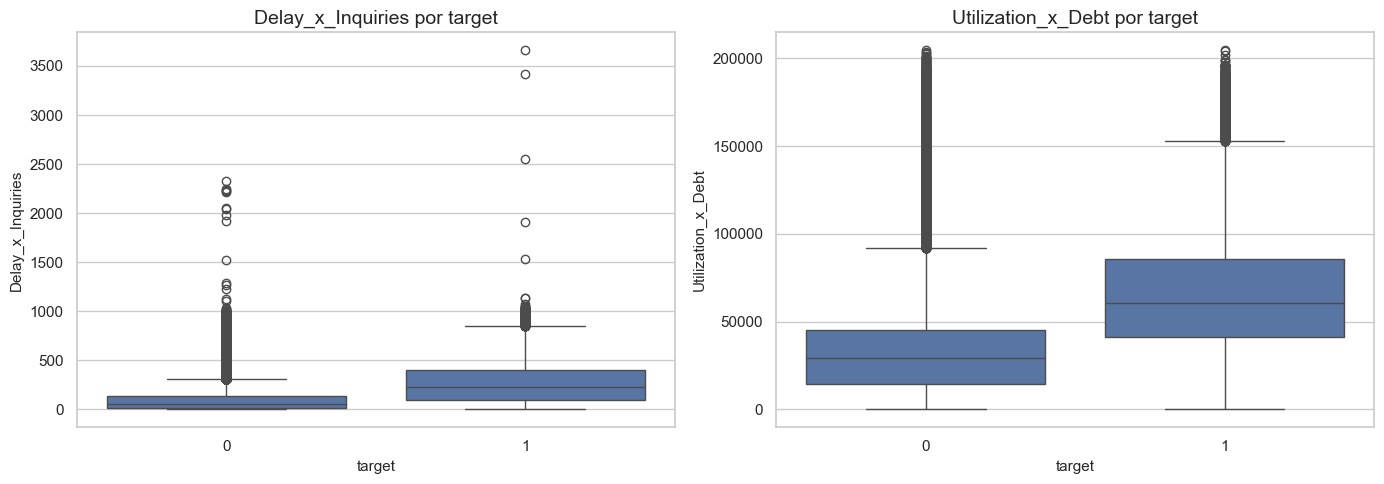

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, interaction_cols):
    sns.boxplot(data=df_work, x='target', y=col, ax=ax)
    ax.set_title(f'{col} por target')

plt.tight_layout()
plt.show()

## 8. Decisao: o que entra no `build_features.py`

Com base nos resultados acima, a decisao desta etapa e promover para o pipeline:

- `Loan_Type_Count`
- `Has_Min_Payment_Only`
- `Is_Bad_Credit_Mix`
- `Debt_to_Income_Ratio`
- `EMI_to_Income_Ratio`
- `Invested_to_Income_Ratio`
- `Balance_to_Income_Ratio`
- `Delay_x_Inquiries`
- `Utilization_x_Debt`

As duas ultimas foram adicionadas porque mostraram sinal forte e continuam interpretaveis do ponto de vista de negocio.

In [15]:
df_pipeline = build_features_pipeline(df)
pipeline_feature_cols = [
    'Loan_Type_Count',
    'Has_Min_Payment_Only',
    'Is_Bad_Credit_Mix',
    'Debt_to_Income_Ratio',
    'EMI_to_Income_Ratio',
    'Invested_to_Income_Ratio',
    'Balance_to_Income_Ratio',
    'Delay_x_Inquiries',
    'Utilization_x_Debt'
]

df_pipeline[pipeline_feature_cols + ['target']].head()

,Loan_Type_Count,Has_Min_Payment_Only,Is_Bad_Credit_Mix,Debt_to_Income_Ratio,EMI_to_Income_Ratio,Invested_to_Income_Ratio,Balance_to_Income_Ratio,Delay_x_Inquiries,Utilization_x_Debt,target
0,2,1,1,0.051032,0.015868,0.090442,0.093463,620,41592.306407,0
1,2,1,1,0.051032,0.015868,0.065086,0.115123,682,46011.693758,1
2,2,1,1,0.051032,0.015868,0.040299,0.136215,682,59837.459708,1
3,2,1,1,0.051032,0.015868,0.032485,0.155115,704,51330.780120,1
4,2,1,1,0.051032,0.015868,0.070888,0.113016,737,50529.674519,1


## 9. Conclusão

Trabalho feito nesta analise:

- analise da base tratada
- estudo para inclusão de nvoas features